In [2]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.callbacks import Callback
from datamodules import data_processors
from sklearn.preprocessing import StandardScaler
import sys
print(sys.version)
from rusmodules import eigenvals, geometry
from rusmodules.inverse import get_constants

3.14.6 (main, Jun 10 2026, 10:03:53) [GCC 15.2.0]


In [3]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [4]:
n_pow = 20
def custom_activation(x):
    return (1/n_pow) * torch.log((1 + torch.exp(n_pow * x)) / (1 + torch.exp(n_pow * (x - 1))))
#fin función

# Wrap the function in a Keras custom layer
@keras.saving.register_keras_serializable()
class CustomActivationLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Ensure inputs are Torch tensors
        inputs = torch.tensor(inputs) if not isinstance(inputs, torch.Tensor) else inputs
        return custom_activation(inputs)
    #fin función
#fin clase
path_to_current_model_cubic = "models/cubico_L4.keras"
modelo_cubico = keras.models.load_model(path_to_current_model_cubic)
path_to_current_model_isotropic = "models/isotropico_act_custom_6.keras"
modelo_isotropico = keras.models.load_model(path_to_current_model_isotropic)
stats_modelo_cubico = pd.read_csv(path_to_current_model_cubic[:-6]+"_stats.csv")
stats_modelo_cubico = stats_modelo_cubico.set_index("Unnamed: 0")
dic_stats = dict(map(lambda x: (x, dict(map(lambda y: (y, stats_modelo_cubico[y][x]),stats_modelo_cubico.keys()))), ["mean", "std"]))
modelo_datos = {"model": modelo_cubico, **dic_stats}

N_data = 200
Ng = 6
shape_def = "Parallelepiped"
N_eig_iso = 5
N_eig_cubic = 20
features_cubic = ["eta", "beta"] + list(map(lambda x: "x_" + str(x), range(N_eig_cubic + 1)))
features_iso = ["eta", "beta"] + list(map(lambda x: "eig_moño_" + str(x+1), range(N_eig_iso)))
np.random.seed(53)

In [5]:
geometries = geometry.generate_sphere_surface_points_random(N_data, 0.61*np.pi, np.pi)
geo_df = pd.DataFrame()
geo_df["eta"] = geometries[:,0]
geo_df["beta"] = geometries[:, 1]
print(max(geo_df["eta"])/np.pi)
print(max(geo_df["beta"])/np.pi)

0.5998771903465114
0.9897204352586402


In [6]:
geo_df

,eta,beta
0,0.652248,2.569890
1,1.145582,2.739314
2,1.297174,1.771559
3,1.437671,2.202038
4,1.108993,1.292948
...,...,...
195,1.143443,1.022898
196,1.594526,1.514427
197,1.884570,1.025783
198,1.386203,0.027437


In [7]:
M_max = 150 #GPa
datos_iso = pd.DataFrame()
datos_cubic = pd.DataFrame()
datos_iso["K"] = np.random.uniform(10, M_max, N_data)
datos_iso["G"] = np.random.uniform(10, M_max, N_data)
datos_cubic["K"] = np.random.uniform(10, 2*M_max, N_data)
datos_cubic["mu"] = np.random.uniform(10, M_max, N_data)
datos_cubic["a"] = np.random.uniform(10, (2/3)*M_max, N_data)
datos_cubic["C11"] = datos_cubic["K"] + 2*datos_cubic["a"]
datos_cubic["C12"] = datos_cubic["K"] - datos_cubic["a"]
datos_cubic["C44"] = datos_cubic["mu"]
datos_iso["phi_K"] = np.arctan(datos_iso["G"]/datos_iso["K"])
datos_cubic["phi_K"] = np.arctan(np.sqrt((datos_cubic["a"])**2 + (datos_cubic["mu"])**2)/datos_cubic["K"])
datos_cubic["phi_a"] = np.arctan(datos_cubic["mu"]/datos_cubic["a"])
datos_iso = pd.concat((datos_iso, geo_df), axis = 1)
datos_cubic = pd.concat((datos_cubic, geo_df), axis = 1)

In [8]:
datos_iso

,K,G,phi_K,eta,beta
0,67.968691,81.308633,0.874525,0.652248,2.569890
1,52.970557,70.370286,0.925544,1.145582,2.739314
2,68.279063,64.787223,0.759163,1.297174,1.771559
3,19.018523,72.994951,1.315917,1.437671,2.202038
4,127.919149,40.466621,0.306384,1.108993,1.292948
...,...,...,...,...,...
195,26.940051,33.906572,0.899395,1.143443,1.022898
196,20.016358,118.598762,1.403598,1.594526,1.514427
197,126.183741,100.210629,0.671172,1.884570,1.025783
198,58.744897,87.923693,0.981778,1.386203,0.027437


In [9]:
datos_cubic

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta
0,293.612356,124.845548,58.873492,411.359339,234.738864,124.845548,0.439453,1.130150,0.652248,2.569890
1,247.853881,103.458021,99.946856,447.747592,147.907025,103.458021,0.525871,0.802658,1.145582,2.739314
2,299.675207,62.469695,29.968491,359.612188,269.706716,62.469695,0.227212,1.123497,1.297174,1.771559
3,225.721701,119.288737,98.943868,423.609436,126.777834,119.288737,0.601683,0.878355,1.437671,2.202038
4,188.193591,19.878431,44.810888,277.815366,143.382703,19.878431,0.254825,0.417525,1.108993,1.292948
...,...,...,...,...,...,...,...,...,...,...
195,135.035614,144.018335,18.531795,172.099204,116.503818,144.018335,0.821673,1.442823,1.143443,1.022898
196,207.700838,48.252312,98.242034,404.184905,109.458804,48.252312,0.484990,0.456549,1.594526,1.514427
197,267.267172,98.195014,13.308288,293.883748,253.958884,98.195014,0.355051,1.436088,1.884570,1.025783
198,158.691458,37.067357,20.405766,199.502990,138.285692,37.067357,0.260574,1.067565,1.386203,0.027437


In [10]:
datos_cubic["C11_pred"] = 0.0
datos_cubic["C12_pred"] = 0.0
datos_cubic["C44_pred"] = 0.0

datos_iso["K_pred"] = 0.0
datos_iso["G_pred"] = 0.0
for i in range(N_eig_iso):
  datos_iso[f"eig_{i}"] = 0.0
  datos_iso[f"eig_moño_{i}"] = 0.0

In [11]:
for i in datos_iso.index:
  Ki = datos_iso.at[i, "K"]
  Gi = datos_iso.at[i, "G"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  C_iso = eigenvals.get_elastic_constants({"K": Ki, "mu": Gi})
  eigs_iso = eigenvals.get_eigenvalues(Ng, C_iso, eta_g, beta_g, shape_def)["eig"][:N_eig_iso + 1]
  for j in range(len(eigs_iso)):
    datos_iso.at[i, f"eig_{j}"] = eigs_iso[j]
    if j == 0:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j]
    elif j == 1:
      datos_iso.at[i, f"eig_moño_{j}"] = 1/eigs_iso[j]
    else:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j-1]/eigs_iso[j]

datos_iso["phi_K_pred"] = modelo_isotropico.predict(datos_iso[features_iso])*(np.pi/2)
  

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [12]:
datos_iso[["phi_K", "phi_K_pred", "K", "G", "eig_0"]]

,phi_K,phi_K_pred,K,G,eig_0
0,0.874525,0.883877,67.968691,81.308633,12.299480
1,0.925544,0.979599,52.970557,70.370286,88.447427
2,0.759163,0.797089,68.279063,64.787223,55.733528
3,1.315917,1.346603,19.018523,72.994951,100.315288
4,0.306384,0.423841,127.919149,40.466621,12.521765
...,...,...,...,...,...
195,0.899395,0.947284,26.940051,33.906572,5.759574
196,1.403598,1.440390,20.016358,118.598762,85.744836
197,0.671172,0.665374,126.183741,100.210629,49.808060
198,0.981778,1.027033,58.744897,87.923693,0.000627


In [13]:
for i in datos_iso.index:
  phi_K_p = datos_iso.at[i, "phi_K_pred"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  eig0_ref_l = eigenvals.forward_standard({"phi_K": phi_K_p}, eta_g, beta_g, "Parallelepiped", Ng)["eig"]
  datos_iso.at[i, "eig_ref_0"] = eig0_ref_l[0]
  datos_iso.at[i, "eig_ref_1"] = eig0_ref_l[1]
  datos_iso.at[i, "eig_ref_2"] = eig0_ref_l[2]
  datos_iso.at[i, "eig_ref_3"] = eig0_ref_l[3]
  datos_iso.at[i, "eig_ref_4"] = eig0_ref_l[4]
  datos_iso.at[i, "eig_ref_5"] = eig0_ref_l[5]

datos_iso["M_pred"] = 1/6*(datos_iso["eig_0"]/datos_iso["eig_ref_0"] * ( 1+
                              datos_iso["eig_1"]/datos_iso["eig_ref_1"] +
                              datos_iso["eig_2"]/datos_iso["eig_ref_2"] +
                              datos_iso["eig_3"]/datos_iso["eig_ref_3"] +
                              datos_iso["eig_4"]/datos_iso["eig_ref_4"] +
                              datos_iso["eig_5"]/datos_iso["eig_ref_5"]))
datos_iso["K_pred"] = datos_iso["M_pred"]*np.cos(datos_iso["phi_K_pred"])
datos_iso["G_pred"] = datos_iso["M_pred"]*np.sin(datos_iso["phi_K_pred"])

In [14]:
datos_iso[["K", "K_pred", "G", "G_pred"]]

,K,K_pred,G,G_pred
0,67.968691,66.959239,81.308633,81.640757
1,52.970557,48.357136,70.370286,72.036032
2,68.279063,64.040276,64.787223,65.555366
3,19.018523,17.760065,72.994951,77.885995
4,127.919149,92.153432,40.466621,41.578453
...,...,...,...,...
195,26.940051,24.881173,33.906572,34.594447
196,20.016358,17.885210,118.598762,136.371774
197,126.183741,127.508576,100.210629,100.062595
198,58.744897,54.409899,87.923693,89.999576


In [15]:
datos_iso["K_error"] = 100*np.abs(datos_iso["K"] - datos_iso["K_pred"])/datos_iso["K"]
datos_iso["G_error"] = 100*np.abs(datos_iso["G"] - datos_iso["G_pred"])/datos_iso["G"]

In [16]:
stats_K = data_processors.get_metrics(None, y = datos_iso["K"], model = None, y_gorro = datos_iso["K_pred"])
stats_G = data_processors.get_metrics(None, y = datos_iso["G"], model = None, y_gorro = datos_iso["G_pred"])
stats_fin_iso = pd.DataFrame({"K": stats_K, "G": stats_G})
stats_fin_iso

,K,G
R2,0.919021,0.969853
RMSE,10.611111,6.595448
MAE,6.451640,2.898815
SDAE,8.424488,5.924256


In [17]:
stats_fin_iso.to_csv("../Thesis_Docs/pictures/iso_stats.csv")

In [18]:
datos_iso_emp = datos_iso[datos_iso["K"] > (2/3)*datos_iso["G"]]

In [19]:
datos_iso_emp

,K,G,phi_K,eta,beta,K_pred,G_pred,eig_0,eig_moño_0,eig_1,...,phi_K_pred,eig_ref_0,eig_ref_1,eig_ref_2,eig_ref_3,eig_ref_4,eig_ref_5,M_pred,K_error,G_error
0,67.968691,81.308633,0.874525,0.652248,2.569890,66.959239,81.640757,12.299480,12.299480,1.549128,...,0.883877,0.116362,1.549365,2.653566,5.889079,7.267877,7.968408,105.587656,1.485171,0.408473
1,52.970557,70.370286,0.925544,1.145582,2.739314,48.357136,72.036032,88.447427,88.447427,1.083521,...,0.979599,1.010359,1.119014,1.228522,2.784085,3.941980,3.973366,86.761760,8.709407,2.367116
2,68.279063,64.787223,0.759163,1.297174,1.771559,64.040276,65.555366,55.733528,55.733528,1.251234,...,0.797089,0.615193,1.231323,2.556182,3.974287,4.055838,4.499654,91.644217,6.208033,1.185639
4,127.919149,40.466621,0.306384,1.108993,1.292948,92.153432,41.578453,12.521765,12.521765,1.101170,...,0.423841,0.127098,1.061651,3.988717,4.464089,6.093594,6.937919,101.099075,27.959627,2.747526
6,62.473202,68.725817,0.833020,0.693507,2.122948,54.620692,71.269446,9.275614,9.275614,2.213795,...,0.916883,0.102271,2.219359,2.662741,6.143432,8.582787,10.583449,89.792838,12.569406,3.701127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,39.120937,41.116998,0.810270,1.342030,2.149959,38.029679,41.284854,55.219851,55.219851,1.251042,...,0.826416,0.987717,1.242127,1.972633,3.483980,3.673821,3.770941,56.131059,2.789446,0.408239
195,26.940051,33.906572,0.899395,1.143443,1.022898,24.881173,34.594447,5.759574,5.759574,1.069369,...,0.947284,0.133922,1.099695,4.967697,5.486528,5.542009,6.411699,42.612774,7.642442,2.028735
197,126.183741,100.210629,0.671172,1.884570,1.025783,127.508576,100.062595,49.808060,49.808060,1.458512,...,0.665374,0.306865,1.461518,3.897885,4.306121,4.386422,5.937758,162.083189,1.049926,0.147723
198,58.744897,87.923693,0.981778,1.386203,0.027437,54.409899,89.999576,0.000627,0.000627,1.382096,...,1.027033,0.000006,1.340895,2.821967,5.559493,7.012462,10.825141,105.168250,7.379361,2.361004


In [20]:
stats_K_emp = data_processors.get_metrics(None, y = datos_iso_emp["K"], model = None, y_gorro = datos_iso_emp["K_pred"])
stats_G_emp = data_processors.get_metrics(None, y = datos_iso_emp["G"], model = None, y_gorro = datos_iso_emp["G_pred"])
stats_fin_iso_emp = pd.DataFrame({"K": stats_K_emp, "G": stats_G_emp})
stats_fin_iso_emp

,K,G
R2,0.840619,0.998201
RMSE,12.596749,1.437916
MAE,8.136271,0.857838
SDAE,9.616609,1.154000


In [21]:
stats_fin_iso_emp.to_csv("../Thesis_Docs/pictures/iso_stats_empirical.csv")

/tmp/nix-shell-16040-1174774205/ipykernel_17365/1645654432.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right")
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


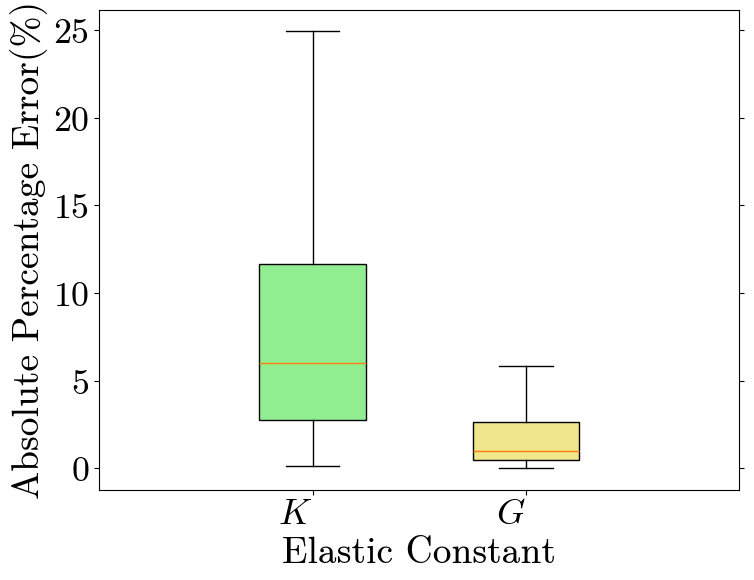

In [22]:
fig_boxKG = plt.figure()
labels_fontsize = 27
keys_reporte = ("K_error", "G_error")
keys_boxplot = (r"$K$", r"$G$")
custom_positions = [1.0, 1.2]
box_width = 0.1
ax2 = fig_boxKG.add_axes([0, 0, 1, 1])
data2 = [datos_iso[key] for key in keys_reporte]
ax2.set_xlim(0.8, 1.4)
ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right") 
ax2.set_xlabel("Elastic Constant", fontsize = labels_fontsize)
ax2.set_ylabel("Absolute Percentage Error(%)", fontsize = labels_fontsize)
ax2.yaxis.set_ticks_position('both') 
medians = [np.median(d) for d in data2]
#ax2.axhline(5, color='red', linestyle='--', linewidth=1.5)
bp2 = ax2.boxplot(data2, showfliers=False, patch_artist=True, positions=custom_positions, widths=box_width)
colors = ['lightgreen', 'khaki', 'lightblue']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.tick_params(axis='x', labelsize=26, rotation = "auto")
ax2.tick_params(axis='y', labelsize=26)

plt.savefig("../Thesis_Docs/pictures/figBOX_iso.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


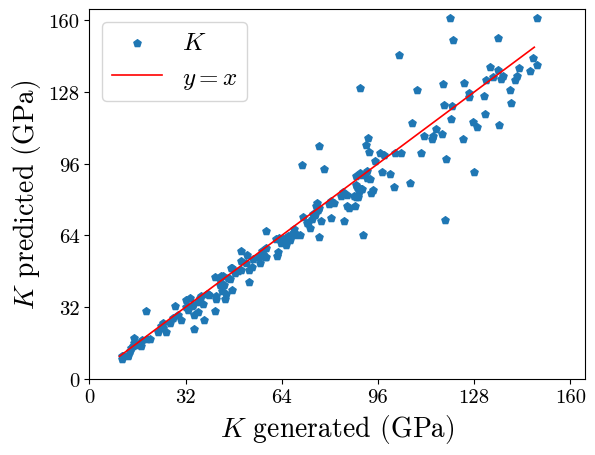

In [23]:
fig_K = plt.figure()
ax1 =fig_K.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["K"])), int(max(datos_iso["K"])))
ax1.scatter(datos_iso["K"], datos_iso["K_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$K$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$K$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["K_pred"]) - 5, 165)
ax1.set_xlim(min(datos_iso["K"]) - 5, 165)
ticks = np.linspace(0, 160, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$K$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_K.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


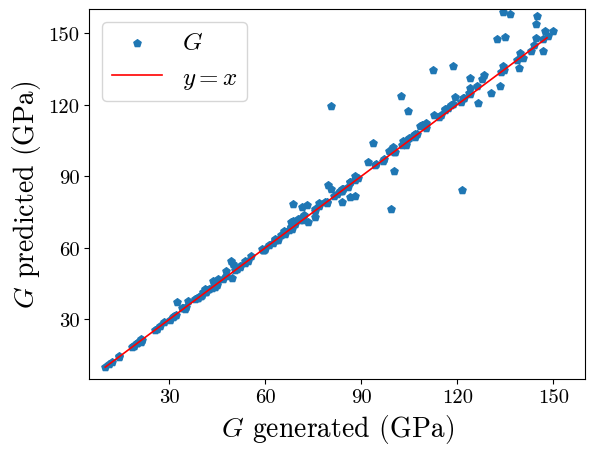

In [24]:
fig_G = plt.figure()
ax1 =fig_G.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["G"])), int(max(datos_iso["G"])))
ax1.scatter(datos_iso["G"], datos_iso["G_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$G$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$G$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["G"]), max(datos_iso["G"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ticks = np.linspace(0, 150, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_ylim(min(datos_iso["G_pred"]) - 5, 160)
ax1.set_xlim(min(datos_iso["G"]) - 5 , 160)
ax1.legend([r"$G$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_G.pdf", bbox_inches="tight", pad_inches=0)

In [25]:
for i in datos_cubic.index:
  Ki = datos_cubic.at[i, "K"]
  mui = datos_cubic.at[i, "mu"]
  ai = datos_cubic.at[i, "a"]
  eta_g = datos_cubic.at[i, "eta"]
  beta_g = datos_cubic.at[i, "beta"]
  C_cubic = eigenvals.get_elastic_constants({"K": Ki, "mu": mui, "a": ai})
  eigs_cubic = eigenvals.get_eigenvalues(Ng, C_cubic, eta_g, beta_g, shape_def)["eig"][:N_eig_cubic]
  C_predicted = get_constants(eigs_cubic, eta_g, beta_g, modelo_datos)
  datos_cubic.at[i, "C11_pred"] = C_predicted["C00"]
  datos_cubic.at[i, "C12_pred"] = C_predicted["C01"]
  datos_cubic.at[i, "C44_pred"] = C_predicted["C33"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━

In [26]:
datos_cubic.dropna()

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta,C11_pred,C12_pred,C44_pred
0,293.612356,124.845548,58.873492,411.359339,234.738864,124.845548,0.439453,1.130150,0.652248,2.569890,420.167867,246.364848,126.862245
1,247.853881,103.458021,99.946856,447.747592,147.907025,103.458021,0.525871,0.802658,1.145582,2.739314,456.521814,155.142720,102.904455
2,299.675207,62.469695,29.968491,359.612188,269.706716,62.469695,0.227212,1.123497,1.297174,1.771559,343.714956,252.425982,61.602021
3,225.721701,119.288737,98.943868,423.609436,126.777834,119.288737,0.601683,0.878355,1.437671,2.202038,416.532259,119.516132,119.828296
4,188.193591,19.878431,44.810888,277.815366,143.382703,19.878431,0.254825,0.417525,1.108993,1.292948,304.709199,172.619917,19.880892
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,135.035614,144.018335,18.531795,172.099204,116.503818,144.018335,0.821673,1.442823,1.143443,1.022898,192.576950,138.022820,145.379487
196,207.700838,48.252312,98.242034,404.184905,109.458804,48.252312,0.484990,0.456549,1.594526,1.514427,419.895084,125.082923,47.891911
197,267.267172,98.195014,13.308288,293.883748,253.958884,98.195014,0.355051,1.436088,1.884570,1.025783,294.175172,254.991834,103.037367
198,158.691458,37.067357,20.405766,199.502990,138.285692,37.067357,0.260574,1.067565,1.386203,0.027437,229.303220,168.652545,36.244636


In [27]:
datos_graph = datos_cubic.dropna()

In [28]:
print(datos_graph[["C11", "C11_pred", "C12", "C12_pred", "C44", "C44_pred"]])

            C11    C11_pred         C12    C12_pred         C44    C44_pred
0    411.359339  420.167867  234.738864  246.364848  124.845548  126.862245
1    447.747592  456.521814  147.907025  155.142720  103.458021  102.904455
2    359.612188  343.714956  269.706716  252.425982   62.469695   61.602021
3    423.609436  416.532259  126.777834  119.516132  119.288737  119.828296
4    277.815366  304.709199  143.382703  172.619917   19.878431   19.880892
..          ...         ...         ...         ...         ...         ...
195  172.099204  192.576950  116.503818  138.022820  144.018335  145.379487
196  404.184905  419.895084  109.458804  125.082923   48.252312   47.891911
197  293.883748  294.175172  253.958884  254.991834   98.195014  103.037367
198  199.502990  229.303220  138.285692  168.652545   37.067357   36.244636
199  365.926141  296.307366  266.469592  194.461527   49.654333   49.372575

[200 rows x 6 columns]


In [29]:
datos_graph["C11_error"] = 100*np.abs(datos_graph["C11"] - datos_graph["C11_pred"])/datos_graph["C11"]
datos_graph["C12_error"] = 100*np.abs(datos_graph["C12"] - datos_graph["C12_pred"])/np.abs(datos_graph["C12"])
datos_graph["C44_error"] = 100*np.abs(datos_graph["C44"] - datos_graph["C44_pred"])/datos_graph["C44"]

In [30]:
datos_graph["C12_error"].median()

np.float64(10.728933614453544)

In [31]:
stats_C11 = data_processors.get_metrics(None, y = datos_graph["C11"], model = None, y_gorro = datos_graph["C11_pred"])
stats_C12 = data_processors.get_metrics(None, y = datos_graph["C12"], model = None, y_gorro = datos_graph["C12_pred"])
stats_C44 = data_processors.get_metrics(None, y = datos_graph["C44"], model = None, y_gorro = datos_graph["C44_pred"])
stats_fin_cubic = pd.DataFrame({"C11": stats_C11, "C12": stats_C12, "C44": stats_C44})
stats_fin_cubic

,C11,C12,C44
R2,0.820334,0.683385,0.988556
RMSE,40.622625,47.943573,4.236259
MAE,20.368069,24.299875,2.126286
SDAE,35.147396,41.329194,3.663987


In [32]:
stats_fin_cubic.to_csv("../Thesis_Docs/pictures/cubic_stats.csv")

In [33]:
datos_cub_emp = datos_graph[datos_graph["C11"] > datos_graph["C44"]]
datos_cub_emp

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta,C11_pred,C12_pred,C44_pred,C11_error,C12_error,C44_error
0,293.612356,124.845548,58.873492,411.359339,234.738864,124.845548,0.439453,1.130150,0.652248,2.569890,420.167867,246.364848,126.862245,2.141322,4.952731,1.615354
1,247.853881,103.458021,99.946856,447.747592,147.907025,103.458021,0.525871,0.802658,1.145582,2.739314,456.521814,155.142720,102.904455,1.959636,4.892056,0.535064
2,299.675207,62.469695,29.968491,359.612188,269.706716,62.469695,0.227212,1.123497,1.297174,1.771559,343.714956,252.425982,61.602021,4.420660,6.407232,1.388952
3,225.721701,119.288737,98.943868,423.609436,126.777834,119.288737,0.601683,0.878355,1.437671,2.202038,416.532259,119.516132,119.828296,1.670685,5.727895,0.452313
4,188.193591,19.878431,44.810888,277.815366,143.382703,19.878431,0.254825,0.417525,1.108993,1.292948,304.709199,172.619917,19.880892,9.680470,20.391032,0.012380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,135.035614,144.018335,18.531795,172.099204,116.503818,144.018335,0.821673,1.442823,1.143443,1.022898,192.576950,138.022820,145.379487,11.898803,18.470640,0.945124
196,207.700838,48.252312,98.242034,404.184905,109.458804,48.252312,0.484990,0.456549,1.594526,1.514427,419.895084,125.082923,47.891911,3.886879,14.273972,0.746910
197,267.267172,98.195014,13.308288,293.883748,253.958884,98.195014,0.355051,1.436088,1.884570,1.025783,294.175172,254.991834,103.037367,0.099163,0.406739,4.931363
198,158.691458,37.067357,20.405766,199.502990,138.285692,37.067357,0.260574,1.067565,1.386203,0.027437,229.303220,168.652545,36.244636,14.937235,21.959504,2.219530


In [34]:
stats_C11_emp = data_processors.get_metrics(None, y = datos_cub_emp["C11"], model = None, y_gorro = datos_cub_emp["C11_pred"])
stats_C12_emp = data_processors.get_metrics(None, y = datos_cub_emp["C12"], model = None, y_gorro = datos_cub_emp["C12_pred"])
stats_C44_emp = data_processors.get_metrics(None, y = datos_cub_emp["C44"], model = None, y_gorro = datos_cub_emp["C44_pred"])
stats_fin_cubic_emp = pd.DataFrame({"C11": stats_C11_emp, "C12": stats_C12_emp, "C44": stats_C44_emp})
stats_fin_cubic_emp

,C11,C12,C44
R2,0.794972,0.669872,0.988969
RMSE,41.243401,48.672533,4.153692
MAE,20.939564,24.920382,2.064074
SDAE,35.532419,41.808971,3.604547


/tmp/nix-shell-16040-1174774205/ipykernel_17365/3432447261.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right")
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


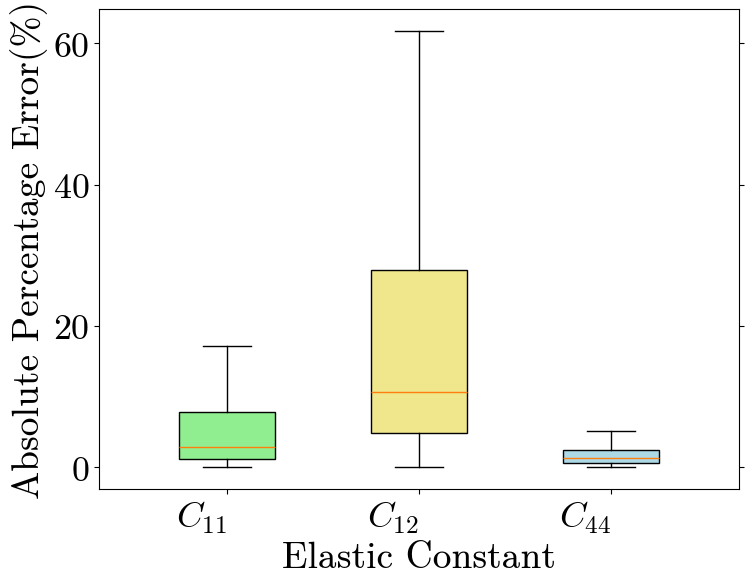

In [35]:
fig_boxCUB = plt.figure()
labels_fontsize = 27
keys_reporte = ("C11_error", "C12_error", "C44_error")
keys_boxplot = (r"$C_{11}$", r"$C_{12}$", r"$C_{44}$")
custom_positions = [1.0, 1.3, 1.6]
box_width = 0.1
ax2 = fig_boxCUB.add_axes([0, 0, 1, 1])
data2 = [datos_graph[key] for key in keys_reporte]
ax2.set_xlim(0.8, 1.8)
ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right") 
ax2.set_xlabel("Elastic Constant", fontsize = labels_fontsize)
ax2.set_ylabel("Absolute Percentage Error(%)", fontsize = labels_fontsize)
ax2.yaxis.set_ticks_position('both') 
medians = [np.median(d) for d in data2]
#ax2.axhline(5, color='red', linestyle='--', linewidth=1.5)
bp2 = ax2.boxplot(data2, showfliers=False, patch_artist=True, positions=custom_positions)
colors = ['lightgreen', 'khaki', 'lightblue']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.tick_params(axis='x', labelsize=26, rotation = "auto")
ax2.tick_params(axis='y', labelsize=26)

plt.savefig("../Thesis_Docs/pictures/figBOX_cubic.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


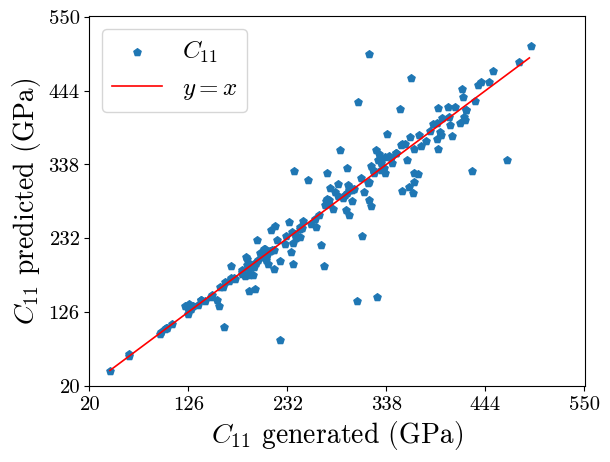

In [36]:
fig_C11 = plt.figure()
ax1 =fig_C11.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C11"])), int(max(datos_graph["C11"])))
ax1.scatter(datos_graph["C11"], datos_graph["C11_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{11}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{11}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C11_pred"]) - 7, 551)#max(datos_graph["C11_pred"]) + 7)
ax1.set_xlim(min(datos_graph["C11_pred"]) - 7, 551) #max(datos_graph["C11_pred"]) + 7)
ticks = np.linspace(20, 550, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{11}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C11.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


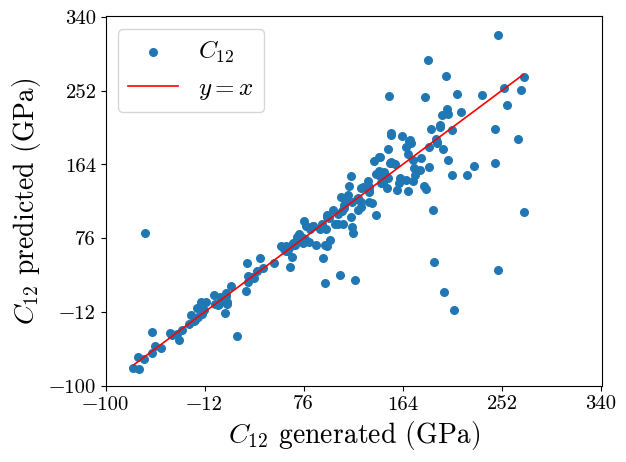

In [37]:
fig_C12 = plt.figure()
ax1 =fig_C12.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C12"])), int(max(datos_graph["C12"])))
ax1.scatter(datos_graph["C12"], datos_graph["C12_pred"], marker="o", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{12}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{12}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C12_pred"]) - 5, 341) #max(datos_graph["C12_pred"]) + 10)
ax1.set_xlim(min(datos_graph["C12"]) - 5, 341) #max(datos_graph["C12_pred"]) + 10)
ticks = np.linspace(-100, 340, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{12}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C12.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


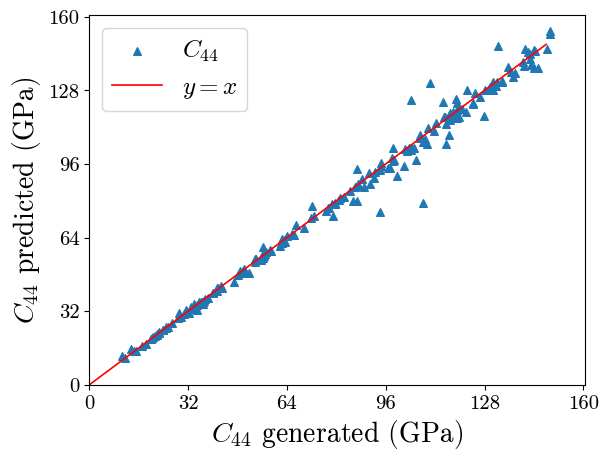

In [38]:
fig_C44 = plt.figure()
ax1 =fig_C44.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(max(datos_graph["C44"])))
ax1.scatter(datos_graph["C44"], datos_graph["C44_pred"], marker="^", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{44}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{44}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C44_pred"]) - 5, max(datos_graph["C44_pred"]) + 7)
ax1.set_xlim(min(datos_graph["C44_pred"]) - 5, max(datos_graph["C44_pred"]) + 7)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ticks = np.linspace(0, 160, 6) 
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.legend([r"$C_{44}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C44.pdf", bbox_inches="tight", pad_inches=0)